<a href="https://colab.research.google.com/github/ahmadouniass/Disaster-Tweets-NLP/blob/main/EDA_disaster_tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌪️ EDA — NLP with Disaster Tweets (Kaggle)

**Objectif** : Explorer le dataset Kaggle *Natural Language Processing with Disaster Tweets* pour comprendre les données avant modélisation.

### Plan :
1. Import des librairies
2. Chargement des données
3. Inspection générale
4. Analyse de la variable cible
5. Valeurs manquantes
6. Keyword & Location
7. Features textuelles
8. Prétraitement + Fréquences des mots
9. WordClouds
10. N-grammes
11. TF-IDF
12. Doublons
13. Train vs Test
14. Hashtags / Mentions / URLs
15. Matrice de corrélation
16. Exemples de tweets
17. Résumé & Insights

## 1. Import des librairies

In [ ]:
import re
import warnings
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
# Téléchargements NLTK (compatibles toutes versions)
for resource in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 42
print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


## 2. Chargement des données

In [ ]:
# Adapter les chemins si nécessaire
TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()

Train shape : (7613, 5)
Test  shape : (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 3. Inspection générale

In [ ]:
print('=== .info() ===')
train.info()

=== .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
print('=== .describe(include=all) ===')
train.describe(include='all')

=== .describe(include=all) ===


,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of Toddler: Report: An 11-year-old boy has been charged with manslaughter ...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


In [ ]:
print('=== Premier tweet ===')
print(train['text'].iloc[0])

=== Premier tweet ===
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all


## 4. Analyse de la variable cible (`target`)

Distribution de la variable target :
        Count  Percentage (%)
target                       
0        4342           57.03
1        3271           42.97


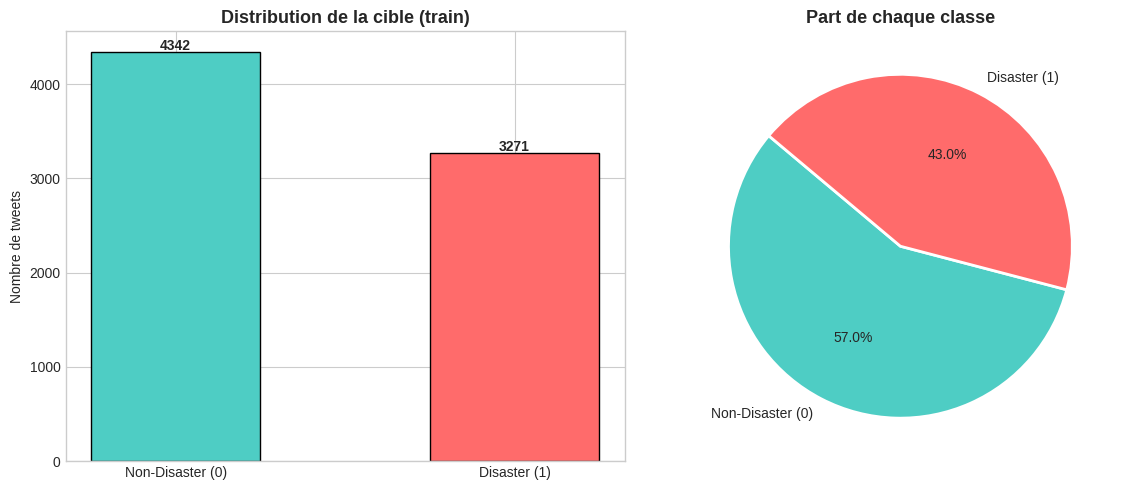

In [ ]:
target_counts = train['target'].value_counts()
target_pct    = train['target'].value_counts(normalize=True) * 100

print('Distribution de la variable target :')
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Non-Disaster (0)', 'Disaster (1)']
colors = ['#4ECDC4', '#FF6B6B']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribution de la cible (train)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Part de chaque classe', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Valeurs manquantes

In [ ]:
def missing_summary(df, name):
    missing     = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({'Missing': missing, 'Missing (%)': missing_pct.round(2)})
    print(f'\n=== Valeurs manquantes — {name} ===')
    return summary[summary['Missing'] > 0]

display(missing_summary(train, 'Train'))
display(missing_summary(test,  'Test'))


=== Valeurs manquantes — Train ===


,Missing,Missing (%)
keyword,61,0.80
location,2533,33.27



=== Valeurs manquantes — Test ===


,Missing,Missing (%)
keyword,26,0.80
location,1105,33.86


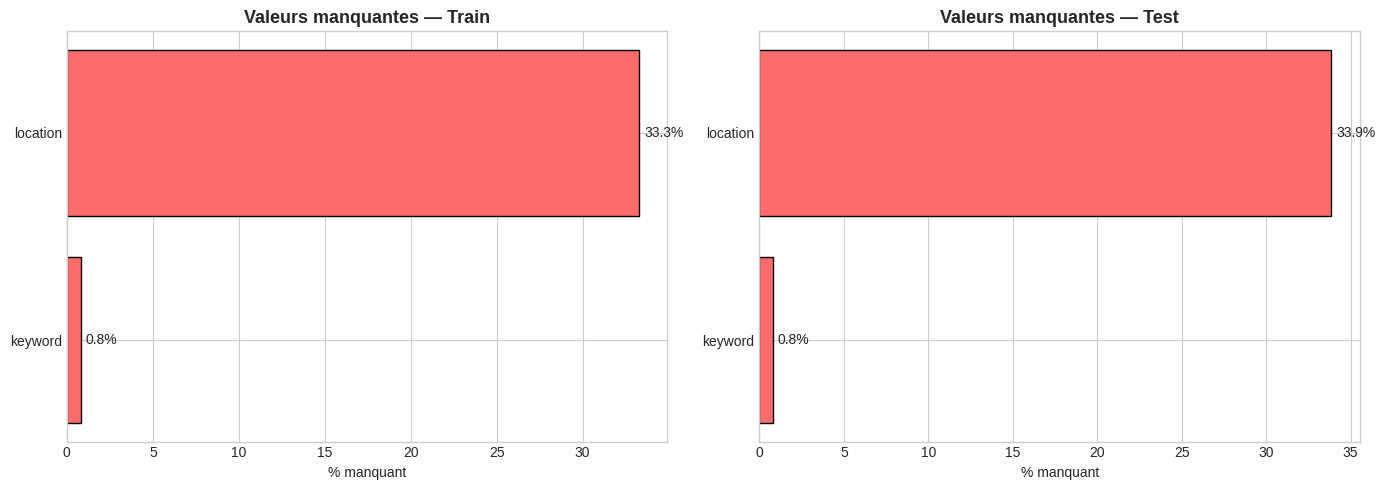

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    mp = df.isnull().mean() * 100
    mp = mp[mp > 0]
    if len(mp) > 0:
        ax.barh(mp.index, mp.values, color='#FF6B6B', edgecolor='black')
        ax.set_xlabel('% manquant')
        ax.set_title(f'Valeurs manquantes — {title}', fontsize=13, fontweight='bold')
        for i, v in enumerate(mp.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    else:
        ax.text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Valeurs manquantes — {title}', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Keyword & Location

### 6.1 Keyword

Keywords uniques (train) : 221
Keywords uniques (test)  : 221


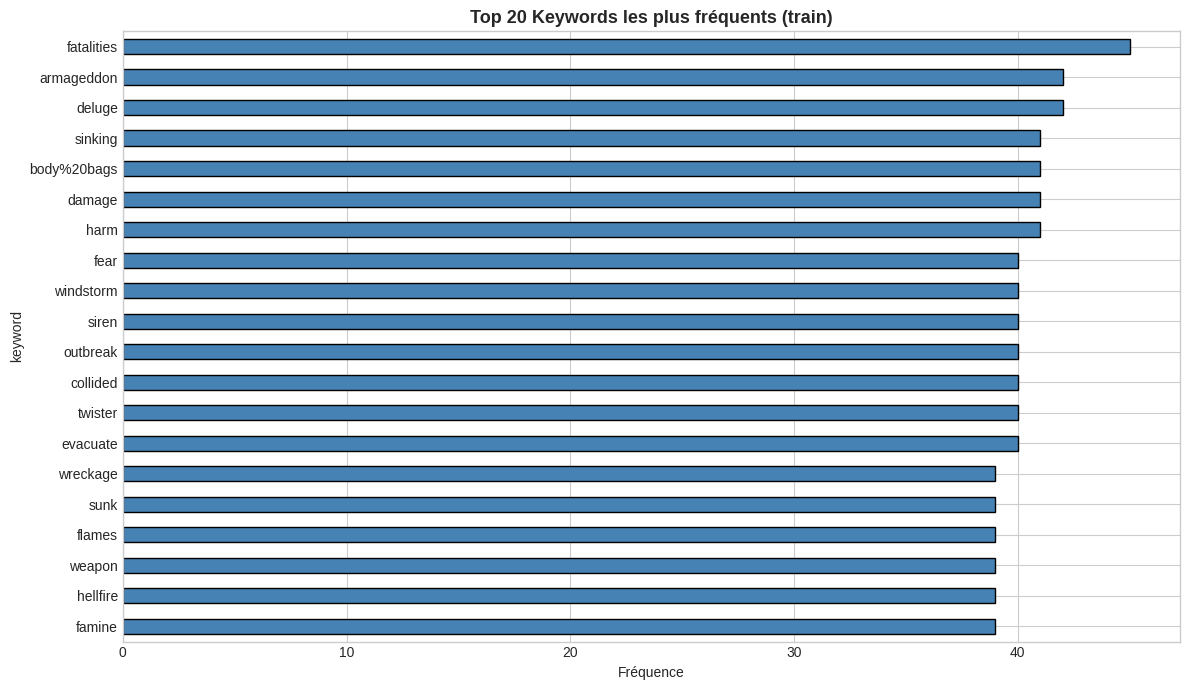

In [ ]:
print(f"Keywords uniques (train) : {train['keyword'].nunique()}")
print(f"Keywords uniques (test)  : {test['keyword'].nunique()}")

top_kw = train['keyword'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_kw.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Keywords les plus fréquents (train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

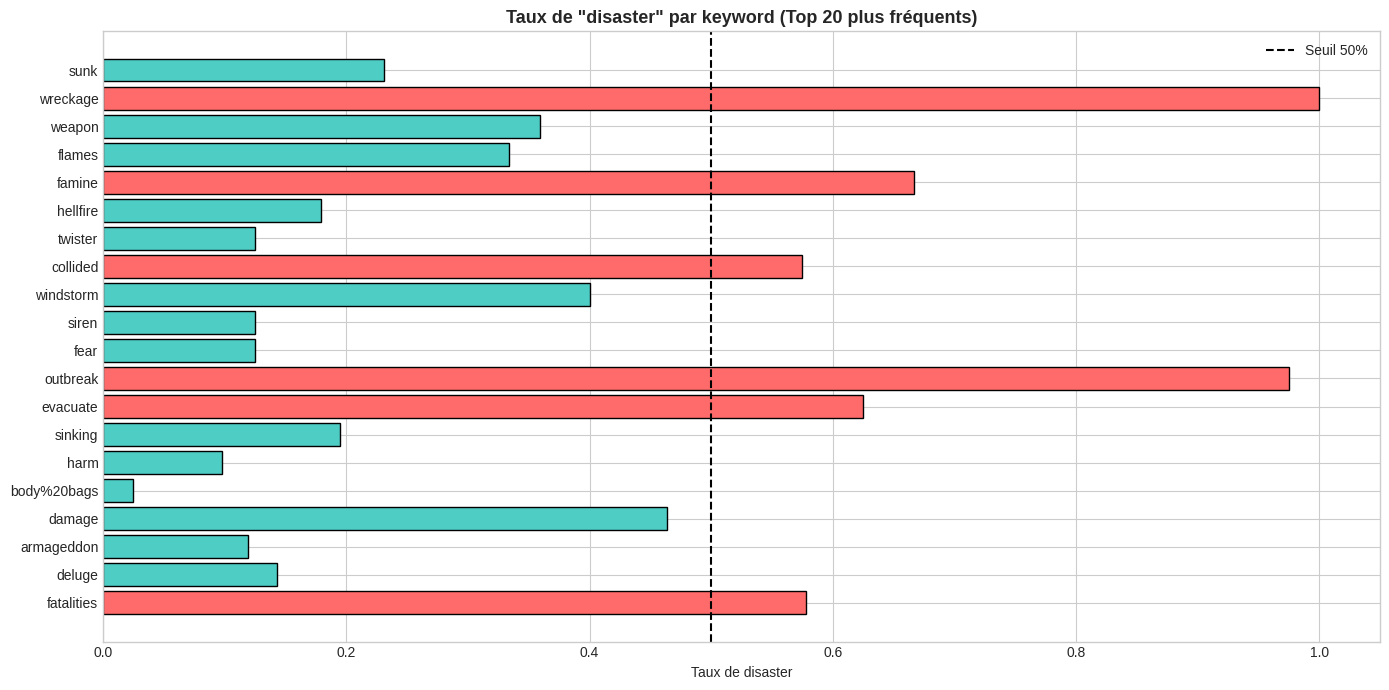

In [ ]:
# Taux de disaster par keyword (top 20)
kw_stats = (
    train.groupby('keyword')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'total'})
    .sort_values('total', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(kw_stats.index, kw_stats['disaster_rate'],
        color=['#FF6B6B' if r > 0.5 else '#4ECDC4' for r in kw_stats['disaster_rate']],
        edgecolor='black')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.set_xlabel('Taux de disaster')
ax.set_title('Taux de "disaster" par keyword (Top 20 plus fréquents)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Location

Locations uniques (train) : 3341


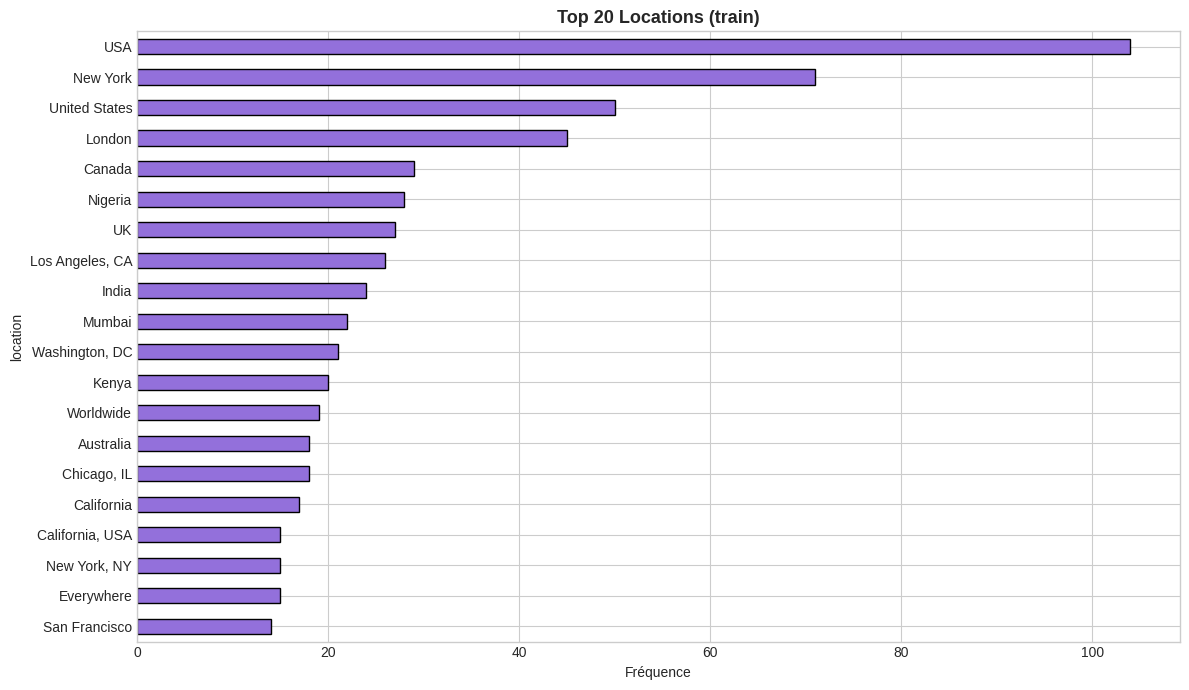

In [ ]:
print(f"Locations uniques (train) : {train['location'].nunique()}")

top_loc = train['location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_loc.sort_values().plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Top 20 Locations (train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

## 7. Features textuelles

In [ ]:
def extract_text_features(df):
    df = df.copy()
    df['char_count']        = df['text'].str.len()
    df['word_count']        = df['text'].str.split().str.len()
    df['unique_word_count'] = df['text'].apply(lambda x: len(set(str(x).split())))
    df['avg_word_length']   = df['text'].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )
    df['url_count']         = df['text'].apply(lambda x: len(re.findall(r'http\S+', str(x))))
    df['mention_count']     = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
    df['hashtag_count']     = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count']    = df['text'].str.count('\\?')
    df['digit_count']       = df['text'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    df['uppercase_count']   = df['text'].apply(lambda x: sum(c.isupper() for c in str(x)))
    return df

train = extract_text_features(train)
test  = extract_text_features(test)
print("✅ Features textuelles ajoutées")
train.head(2)

✅ Features textuelles ajoutées


,id,keyword,location,text,target,char_count,word_count,unique_word_count,avg_word_length,url_count,mention_count,hashtag_count,exclamation_count,question_count,digit_count,uppercase_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,69,13,13,4.384615,0,0,1,0,0,0,10
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,7,7,4.571429,0,0,0,0,0,0,5


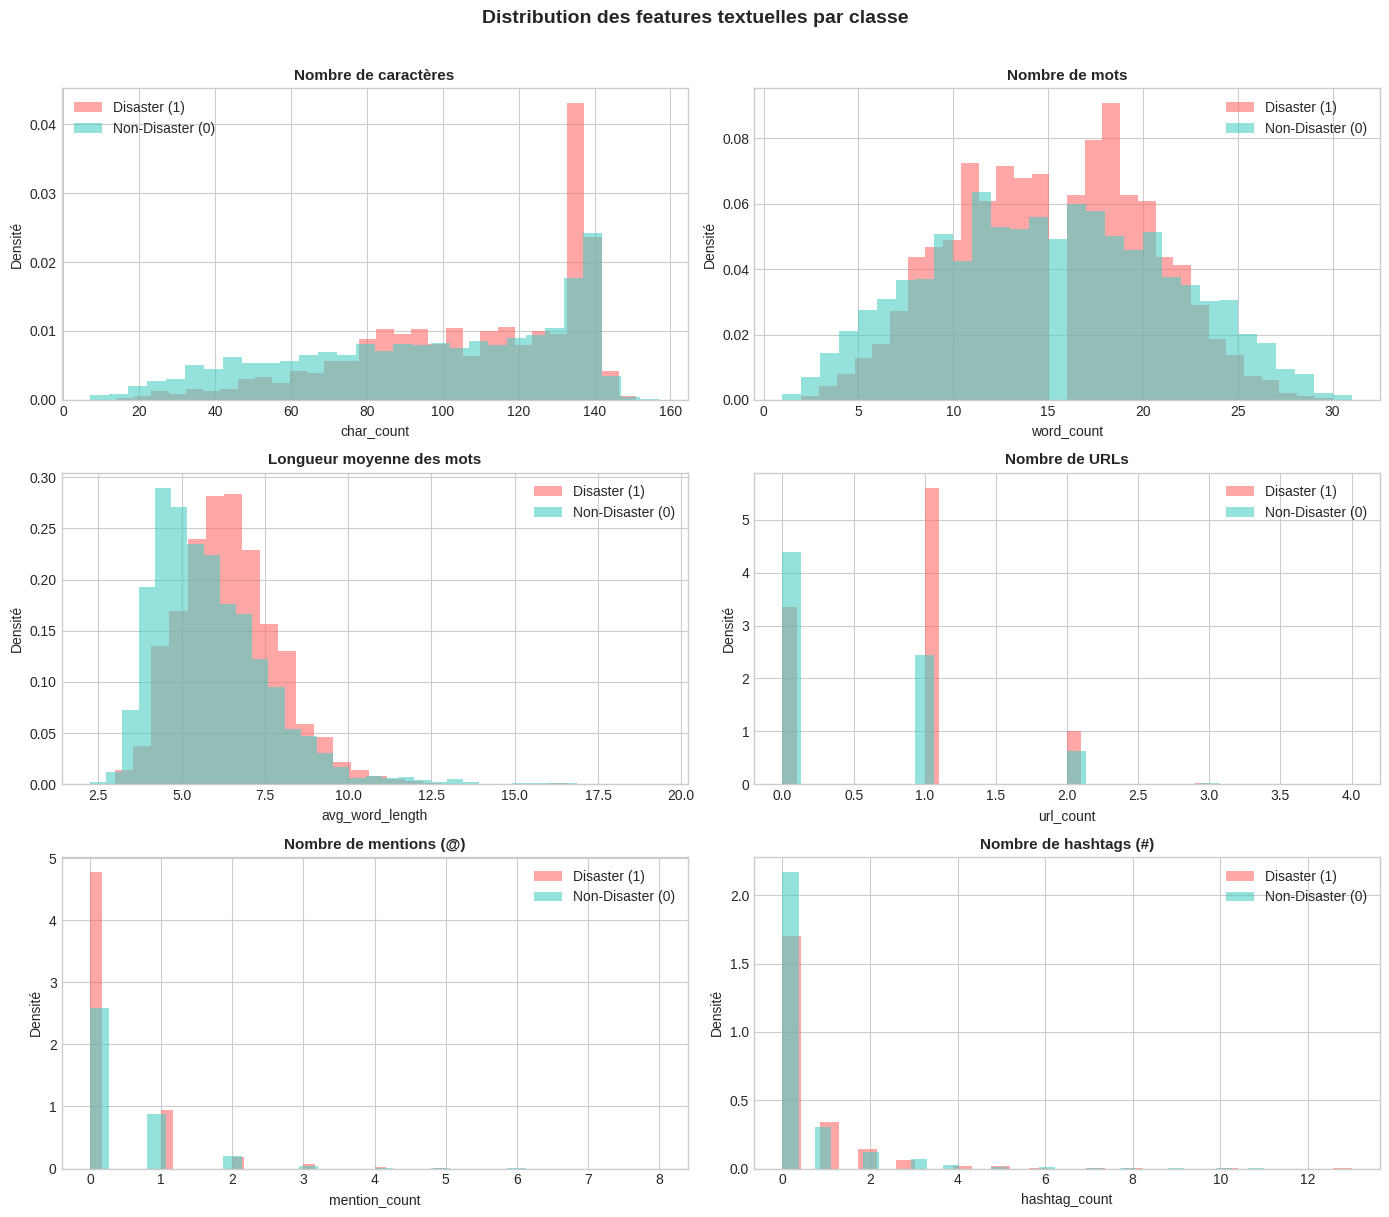

In [ ]:
# Distributions par classe
disaster     = train[train['target'] == 1]
non_disaster = train[train['target'] == 0]

features_to_plot = [
    ('char_count',      'Nombre de caractères'),
    ('word_count',      'Nombre de mots'),
    ('avg_word_length', 'Longueur moyenne des mots'),
    ('url_count',       'Nombre de URLs'),
    ('mention_count',   'Nombre de mentions (@)'),
    ('hashtag_count',   'Nombre de hashtags (#)'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (feat, label) in enumerate(features_to_plot):
    axes[i].hist(disaster[feat],     bins=30, alpha=0.6, color='#FF6B6B', label='Disaster (1)',     density=True)
    axes[i].hist(non_disaster[feat], bins=30, alpha=0.6, color='#4ECDC4', label='Non-Disaster (0)', density=True)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des features textuelles par classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Prétraitement + Fréquences des mots

### 8.1 Prétraitement

In [ ]:
STOPWORDS_EN = set(stopwords.words('english'))

def basic_clean(text):
    """Nettoyage basique : lower, suppression URLs/mentions/ponctuation."""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_no_stop(text):
    """Tokenisation simple + suppression stopwords + mots courts."""
    tokens = basic_clean(text).split()  # .split() plus robuste que word_tokenize
    return [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]

# Appliquer sur train
train['clean_text'] = train['text'].apply(basic_clean)
train['tokens']     = train['text'].apply(tokenize_no_stop)

# ⚠️ Recréer disaster / non_disaster APRÈS ajout de tokens
disaster     = train[train['target'] == 1].copy()
non_disaster = train[train['target'] == 0].copy()

print('Exemple de tweet original :')
print(train['text'].iloc[0])
print('\nAprès nettoyage :')
print(train['clean_text'].iloc[0])
print('\nTokens :')
print(train['tokens'].iloc[0])

Exemple de tweet original :
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Après nettoyage :
our deeds are the reason of this earthquake may allah forgive us all

Tokens :
['deeds', 'reason', 'earthquake', 'may', 'allah', 'forgive']


### 8.2 Fréquences globales (tous tweets)

In [ ]:
# Fréquence globale (tous les tweets du train)
all_tokens = [t for tokens in train['tokens'] for t in tokens]
word_freq  = Counter(all_tokens)

print(f'Vocabulaire (tokens uniques, sans stopwords) : {len(word_freq)}')
print('\nTop 30 mots les plus fréquents :')
print(word_freq.most_common(30))

Vocabulaire (tokens uniques, sans stopwords) : 13578

Top 30 mots les plus fréquents :
[('like', 348), ('amp', 344), ('fire', 254), ('get', 229), ('new', 227), ('via', 220), ('news', 207), ('people', 199), ('one', 199), ('video', 165), ('disaster', 158), ('emergency', 158), ('police', 143), ('would', 137), ('body', 131), ('time', 130), ('still', 129), ('california', 121), ('storm', 121), ('burning', 121), ('day', 120), ('back', 120), ('crash', 119), ('suicide', 119), ('man', 117), ('got', 114), ('know', 113), ('buildings', 111), ('first', 109), ('world', 106)]


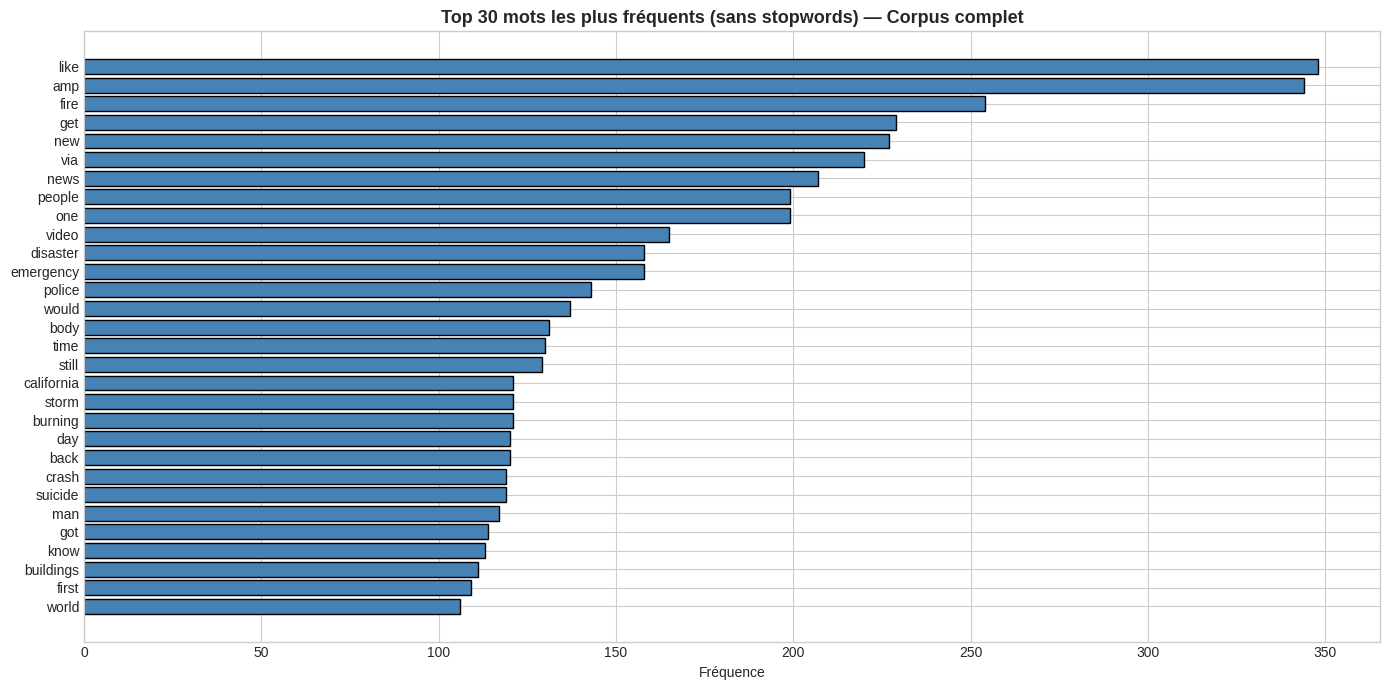

In [ ]:
top30 = pd.DataFrame(word_freq.most_common(30), columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top30['word'][::-1], top30['count'][::-1], color='steelblue', edgecolor='black')
ax.set_title('Top 30 mots les plus fréquents (sans stopwords) — Corpus complet', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

### 8.3 Fréquences par classe

In [ ]:
# Fréquences séparées par classe
tokens_disaster     = [t for tokens in disaster['tokens']     for t in tokens]
tokens_non_disaster = [t for tokens in non_disaster['tokens'] for t in tokens]

freq_disaster     = Counter(tokens_disaster)
freq_non_disaster = Counter(tokens_non_disaster)

print(f'Tokens disaster     : {len(tokens_disaster)} ({len(freq_disaster)} uniques)')
print(f'Tokens non-disaster : {len(tokens_non_disaster)} ({len(freq_non_disaster)} uniques)')

Tokens disaster     : 29298 (7482 uniques)
Tokens non-disaster : 34518 (9771 uniques)


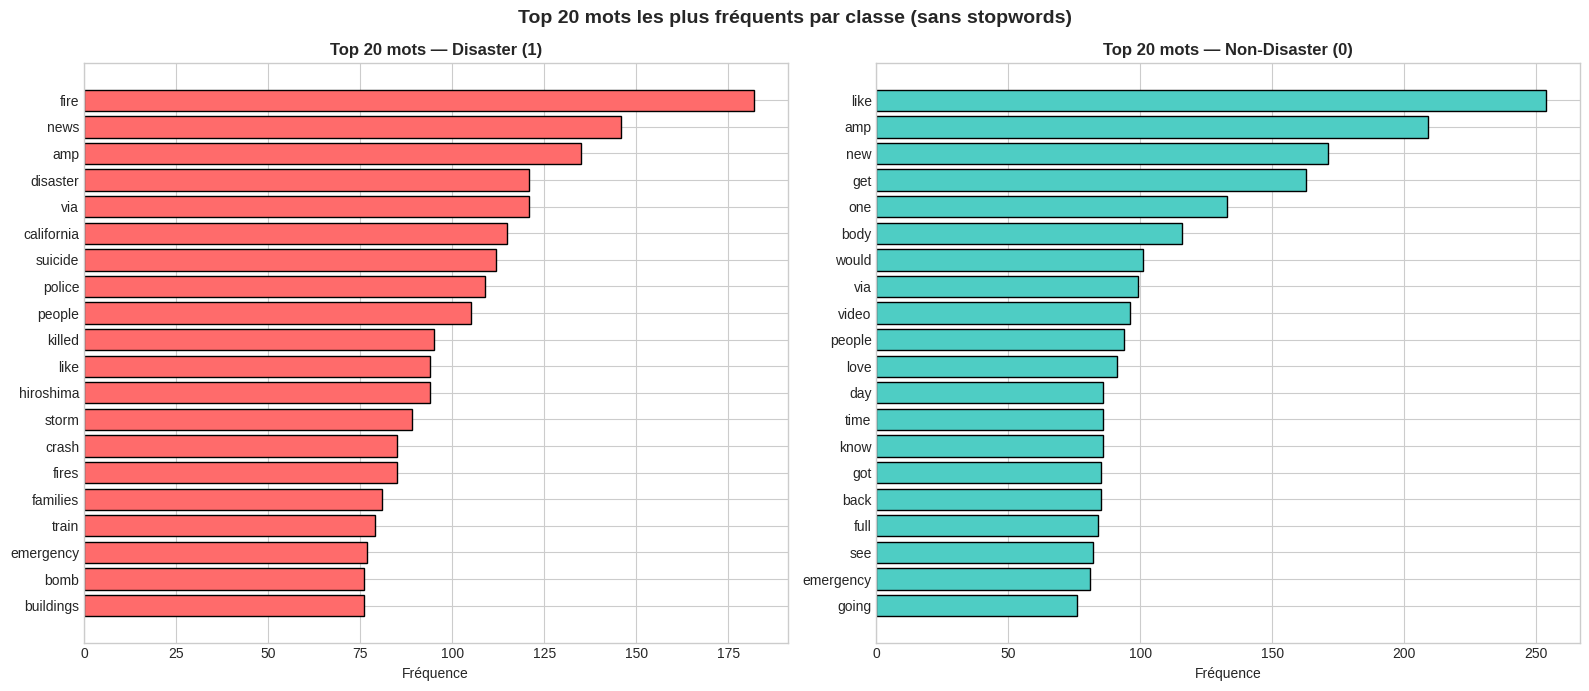

In [ ]:
top_dis  = pd.DataFrame(freq_disaster.most_common(20),     columns=['word', 'count'])
top_ndis = pd.DataFrame(freq_non_disaster.most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_dis['word'][::-1], top_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 mots — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(top_ndis['word'][::-1], top_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 mots — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 mots les plus fréquents par classe (sans stopwords)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. WordClouds par classe

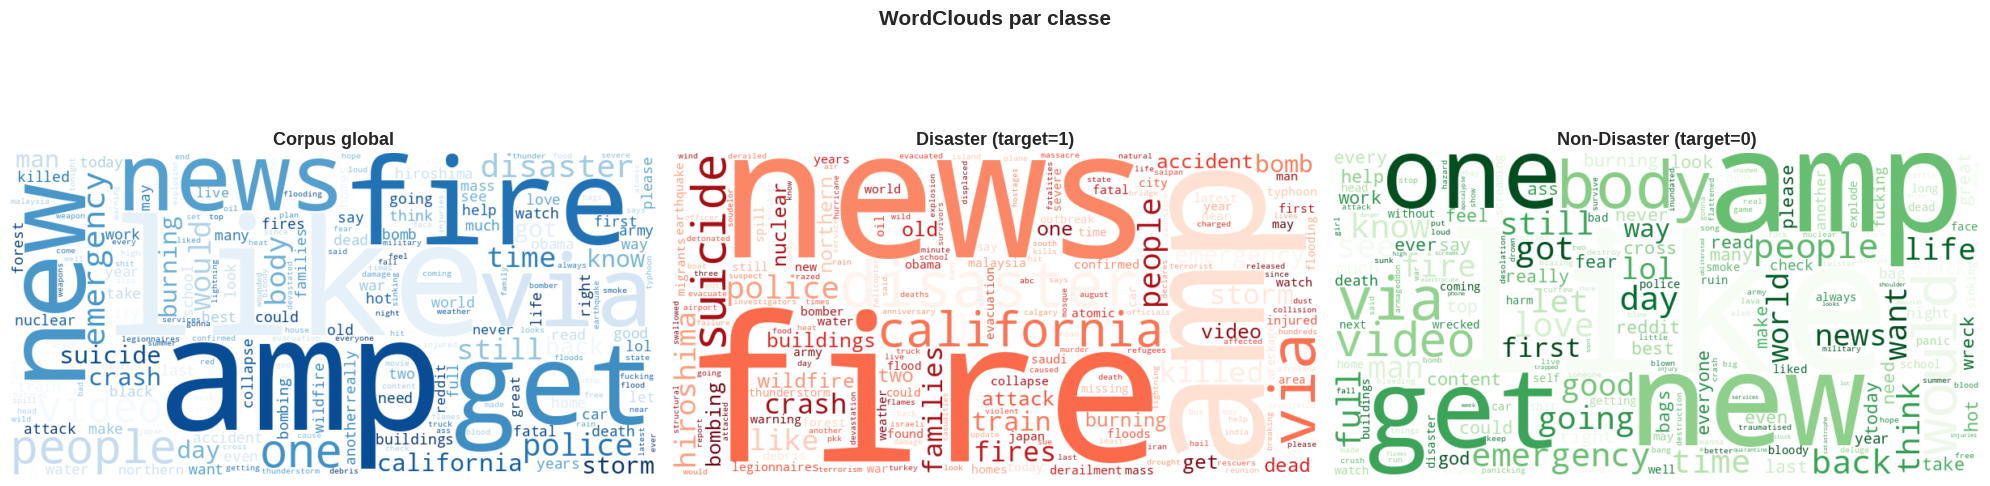

In [ ]:
def make_wordcloud(word_dict, background_color='white', colormap='Blues'):
    wc = WordCloud(
        background_color=background_color,
        max_words=200,
        colormap=colormap,
        collocations=False,
        width=800, height=400
    ).generate_from_frequencies(word_dict)
    return wc

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Global
wc_all = make_wordcloud(dict(word_freq), colormap='Blues')
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Corpus global', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Disaster
wc_dis = make_wordcloud(dict(freq_disaster), colormap='Reds')
axes[1].imshow(wc_dis, interpolation='bilinear')
axes[1].set_title('Disaster (target=1)', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Non-Disaster
wc_ndis = make_wordcloud(dict(freq_non_disaster), colormap='Greens')
axes[2].imshow(wc_ndis, interpolation='bilinear')
axes[2].set_title('Non-Disaster (target=0)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('WordClouds par classe', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. N-grammes

### 10.1 Bigrammes

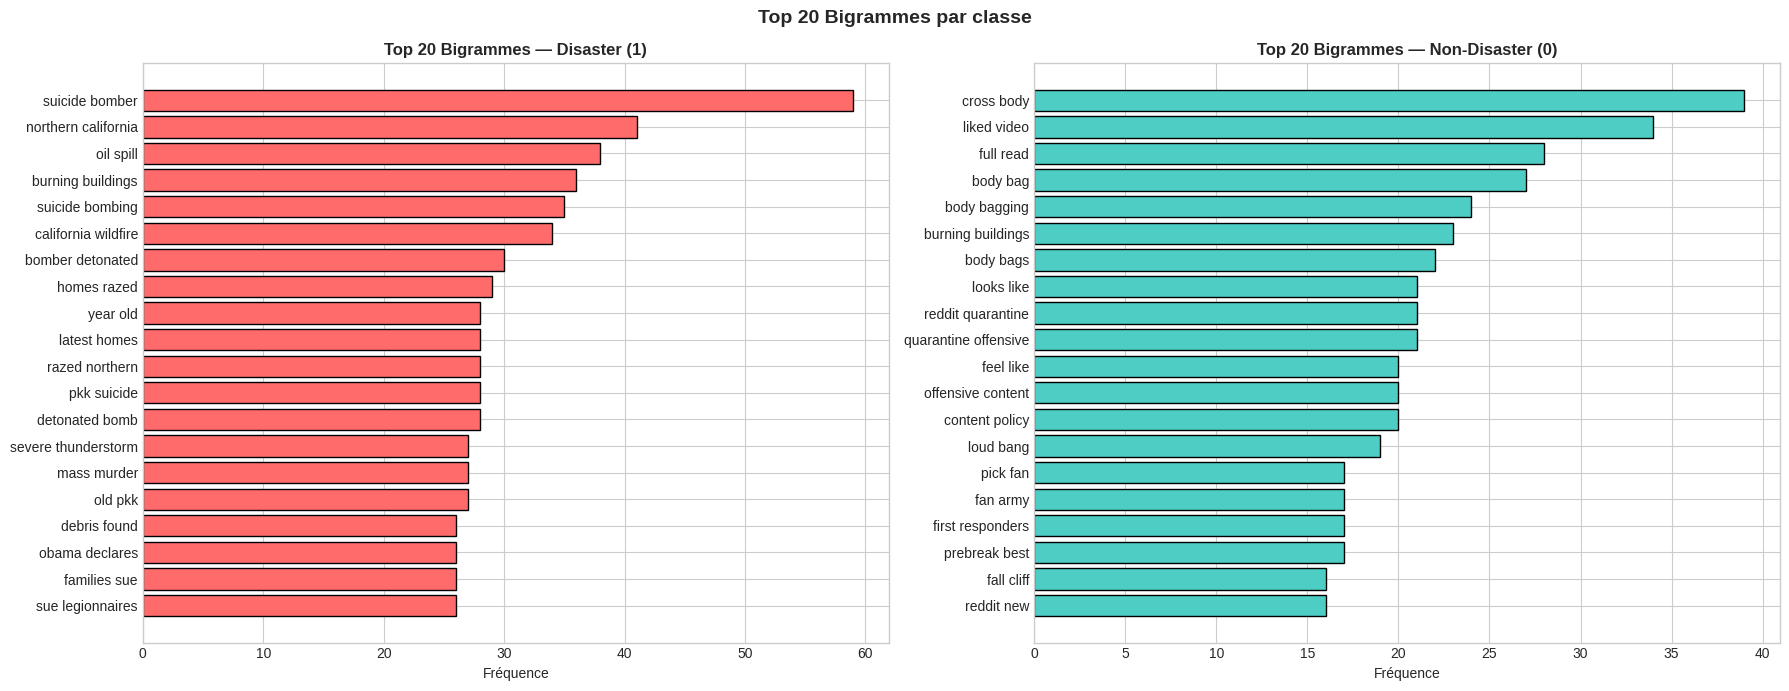

In [ ]:
def get_ngram_freq(token_series, n=2, top_k=20):
    all_ngrams = []
    for tokens in token_series:
        all_ngrams.extend(list(ngrams(tokens, n)))
    ngram_freq = Counter(all_ngrams)
    top = pd.DataFrame(
        [(' '.join(gram), count) for gram, count in ngram_freq.most_common(top_k)],
        columns=['ngram', 'count']
    )
    return top

bi_dis  = get_ngram_freq(disaster['tokens'],     n=2)
bi_ndis = get_ngram_freq(non_disaster['tokens'], n=2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(bi_dis['ngram'][::-1], bi_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 Bigrammes — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(bi_ndis['ngram'][::-1], bi_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 Bigrammes — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 Bigrammes par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Trigrammes

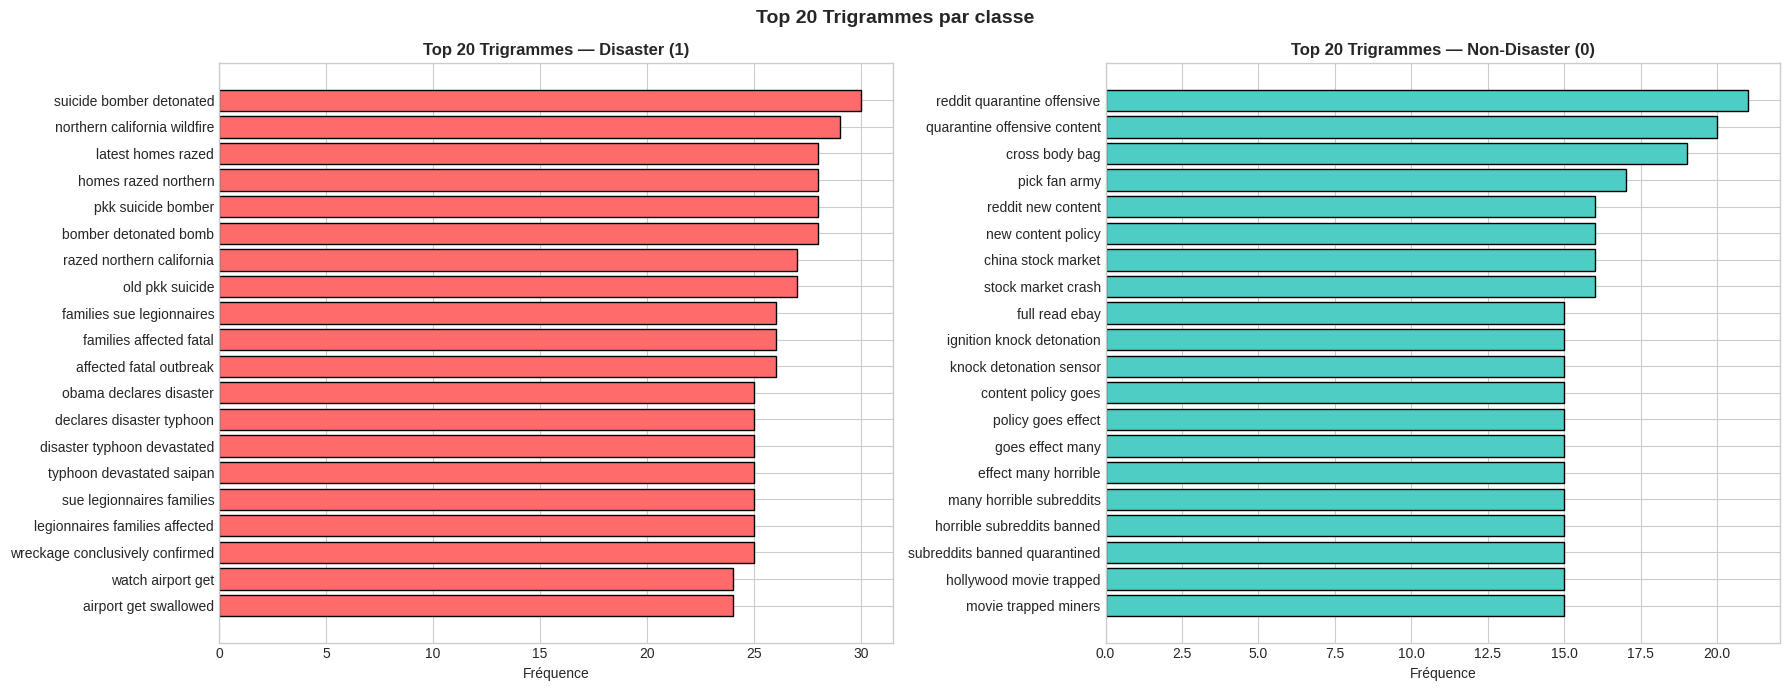

In [ ]:
tri_dis  = get_ngram_freq(disaster['tokens'],     n=3)
tri_ndis = get_ngram_freq(non_disaster['tokens'], n=3)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(tri_dis['ngram'][::-1], tri_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 Trigrammes — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(tri_ndis['ngram'][::-1], tri_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 Trigrammes — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 Trigrammes par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Analyse TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    stop_words='english',
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(train['clean_text'])
feature_names = tfidf.get_feature_names_out()

print(f'Matrice TF-IDF : {X_tfidf.shape}')
print(f'Nombre de features : {len(feature_names)}')

Matrice TF-IDF : (7613, 3353)
Nombre de features : 3353


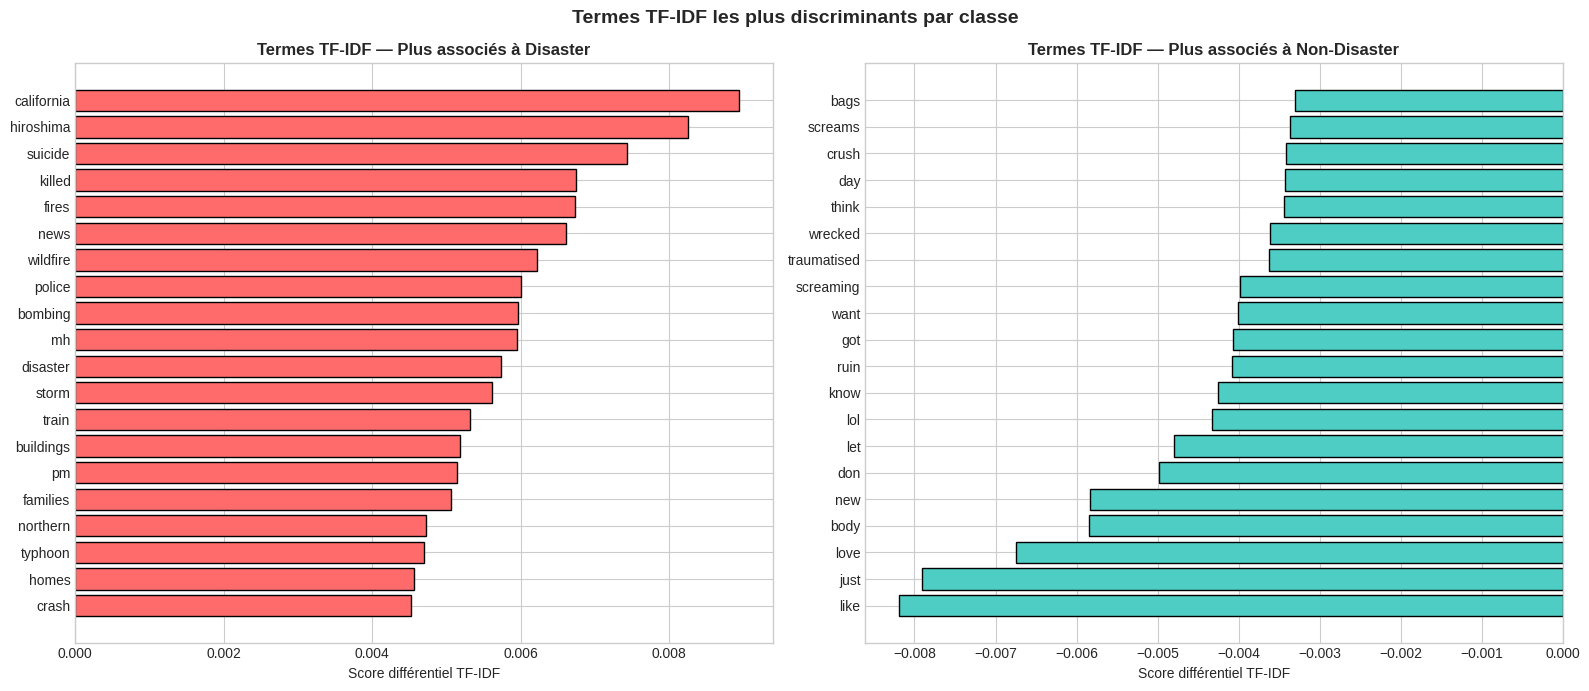

In [ ]:
# Score TF-IDF moyen par terme et par classe
mask_dis  = train['target'].values == 1
mask_ndis = train['target'].values == 0

mean_tfidf_dis  = np.asarray(X_tfidf[mask_dis].mean(axis=0)).flatten()
mean_tfidf_ndis = np.asarray(X_tfidf[mask_ndis].mean(axis=0)).flatten()

diff_score = mean_tfidf_dis - mean_tfidf_ndis

top_dis_terms  = pd.Series(diff_score, index=feature_names).nlargest(20)
top_ndis_terms = pd.Series(diff_score, index=feature_names).nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_dis_terms.index[::-1], top_dis_terms.values[::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Termes TF-IDF — Plus associés à Disaster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score différentiel TF-IDF')

axes[1].barh(top_ndis_terms.index, top_ndis_terms.values, color='#4ECDC4', edgecolor='black')
axes[1].set_title('Termes TF-IDF — Plus associés à Non-Disaster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score différentiel TF-IDF')

plt.suptitle('Termes TF-IDF les plus discriminants par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Doublons

In [ ]:
dup_text = train[train.duplicated('text', keep=False)]
print(f'Tweets en doublon (texte identique) : {len(dup_text)} ({len(dup_text)/len(train)*100:.1f}%)')

dup_conflict = (
    train.groupby('text')['target']
    .nunique()
    .reset_index()
    .query('target > 1')
)
print(f'Tweets avec labels conflictuels : {len(dup_conflict)}')

if len(dup_conflict) > 0:
    print('\nExemples de tweets ambigus :')
    conflict_examples = train[train['text'].isin(dup_conflict['text'].head(3))]
    print(conflict_examples[['text', 'target']].to_string())

Tweets en doublon (texte identique) : 179 (2.4%)
Tweets avec labels conflictuels : 18

Exemples de tweets ambigus :
                                                                                                                                            text  target
2830      .POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4       1
2831      .POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4       1
2832      .POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4       0
2833      .POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4       1
4221                       #foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazard

## 13. Train vs Test

Vocabulaire train   : 13578
Vocabulaire test    : 8380
Mots en commun      : 5271 (38.8% du train)
Exclusifs au train  : 8307
Exclusifs au test   : 3109


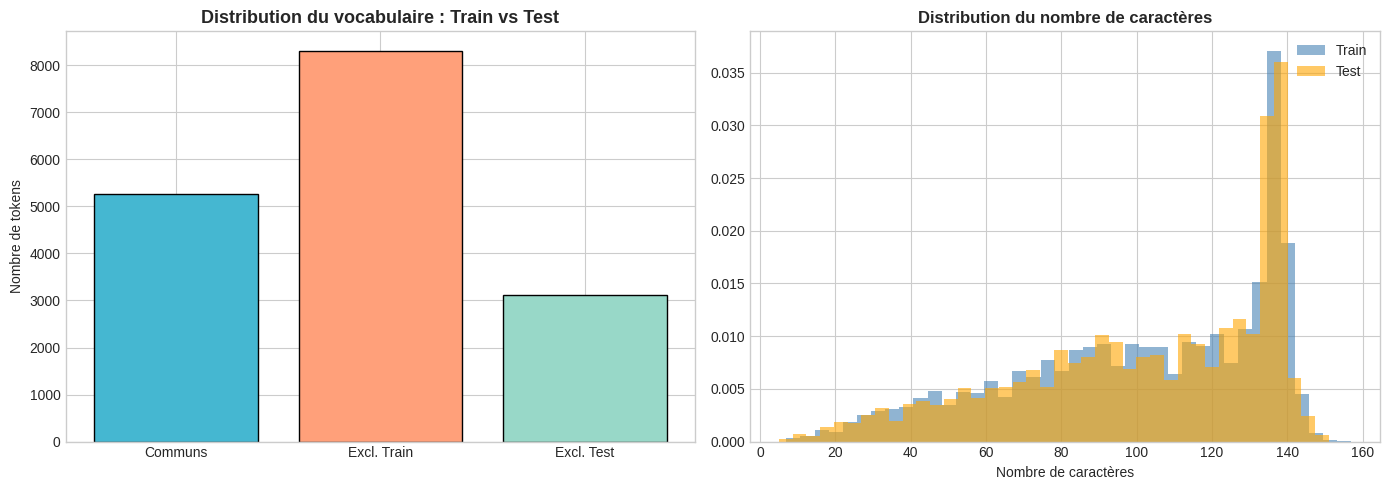

In [ ]:
test['clean_text'] = test['text'].apply(basic_clean)
test['tokens']     = test['text'].apply(tokenize_no_stop)

vocab_train = set(t for toks in train['tokens'] for t in toks)
vocab_test  = set(t for toks in test['tokens']  for t in toks)

common     = vocab_train & vocab_test
only_train = vocab_train - vocab_test
only_test  = vocab_test  - vocab_train

print(f'Vocabulaire train   : {len(vocab_train)}')
print(f'Vocabulaire test    : {len(vocab_test)}')
print(f'Mots en commun      : {len(common)} ({len(common)/len(vocab_train)*100:.1f}% du train)')
print(f'Exclusifs au train  : {len(only_train)}')
print(f'Exclusifs au test   : {len(only_test)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Communs', 'Excl. Train', 'Excl. Test'],
            [len(common), len(only_train), len(only_test)],
            color=['#45B7D1', '#FFA07A', '#98D8C8'], edgecolor='black')
axes[0].set_title('Distribution du vocabulaire : Train vs Test', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tokens')

axes[1].hist(train['char_count'], bins=40, alpha=0.6, color='steelblue', label='Train', density=True)
axes[1].hist(test['char_count'],  bins=40, alpha=0.6, color='orange',    label='Test',  density=True)
axes[1].set_title('Distribution du nombre de caractères', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de caractères')
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Hashtags / Mentions / URLs

=== Tweets contenant au moins un pattern special ===
url_count             Total: 52.2%  |  Disaster: 66.4%  |  Non-Disaster: 41.4%
mention_count         Total: 26.4%  |  Disaster: 20.4%  |  Non-Disaster: 30.9%
hashtag_count         Total: 22.9%  |  Disaster: 26.2%  |  Non-Disaster: 20.4%


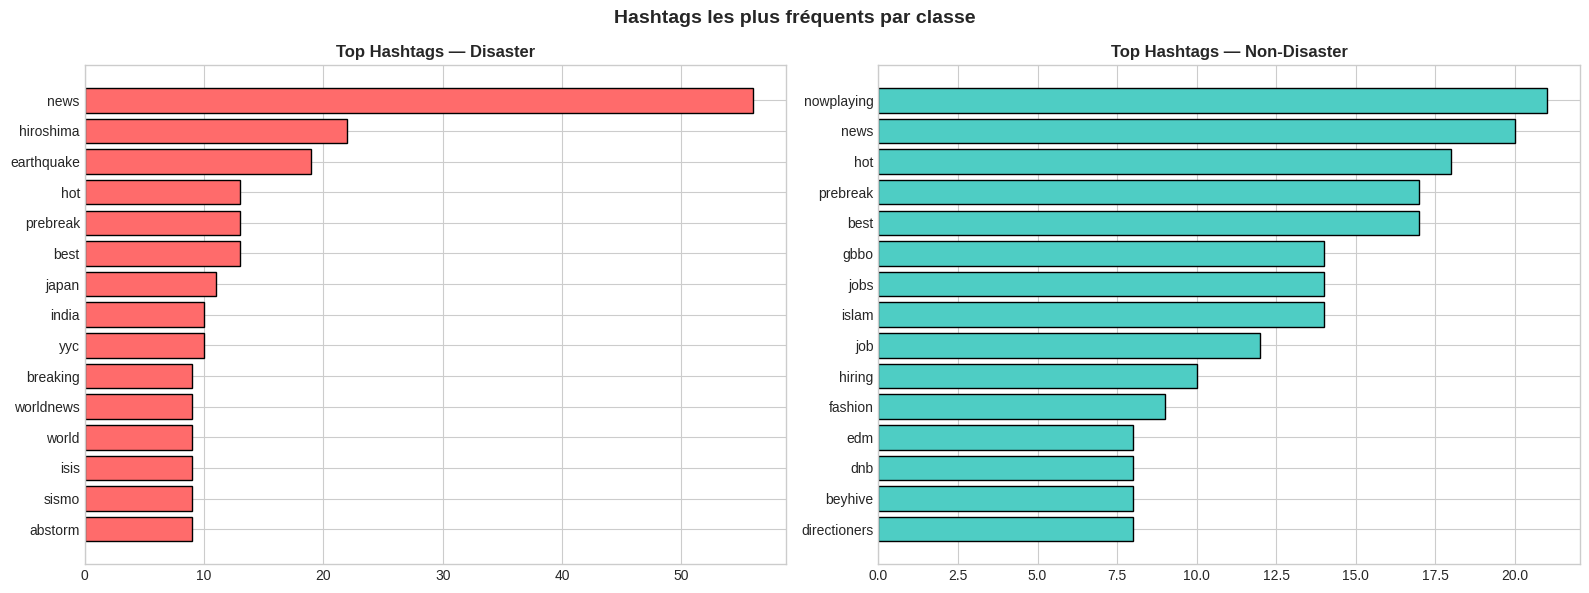

In [ ]:
def pct_with(series, min_val=1):
    return (series >= min_val).mean() * 100

print('=== Tweets contenant au moins un pattern special ===')
for feat in ['url_count', 'mention_count', 'hashtag_count']:
    total = pct_with(train[feat])
    dis   = pct_with(disaster[feat])
    ndis  = pct_with(non_disaster[feat])
    print(f'{feat:20s}  Total: {total:.1f}%  |  Disaster: {dis:.1f}%  |  Non-Disaster: {ndis:.1f}%')

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

hashtags_dis  = [h for text in disaster['text']     for h in extract_hashtags(text)]
hashtags_ndis = [h for text in non_disaster['text'] for h in extract_hashtags(text)]

top_ht_dis  = Counter(hashtags_dis).most_common(15)
top_ht_ndis = Counter(hashtags_ndis).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if top_ht_dis:
    words_d, counts_d = zip(*top_ht_dis)
    axes[0].barh(words_d[::-1], counts_d[::-1], color='#FF6B6B', edgecolor='black')
    axes[0].set_title('Top Hashtags — Disaster', fontsize=12, fontweight='bold')

if top_ht_ndis:
    words_n, counts_n = zip(*top_ht_ndis)
    axes[1].barh(words_n[::-1], counts_n[::-1], color='#4ECDC4', edgecolor='black')
    axes[1].set_title('Top Hashtags — Non-Disaster', fontsize=12, fontweight='bold')

plt.suptitle('Hashtags les plus fréquents par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Matrice de corrélation

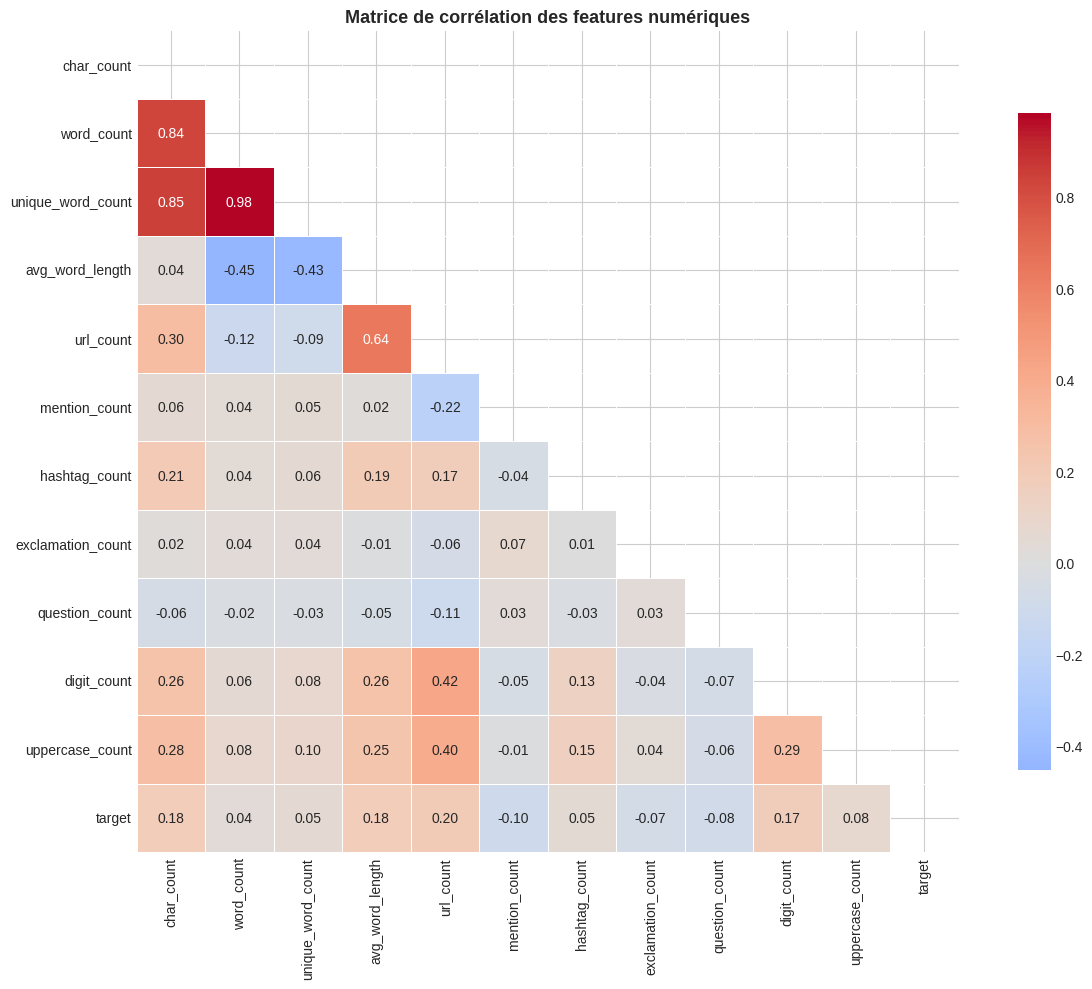

In [ ]:
num_features = [
    'char_count', 'word_count', 'unique_word_count',
    'avg_word_length', 'url_count', 'mention_count',
    'hashtag_count', 'exclamation_count', 'question_count',
    'digit_count', 'uppercase_count', 'target'
]

corr_matrix = train[num_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation des features numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Exemples de tweets par classe

In [ ]:
print('=== Exemples DISASTER (target=1) ===')
for i, row in disaster[['text', 'keyword']].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["text"]}')
    print(f'    keyword: {row["keyword"]}')
    print()

print('=== Exemples NON-DISASTER (target=0) ===')
for i, row in non_disaster[['text', 'keyword']].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["text"]}')
    print(f'    keyword: {row["keyword"]}')
    print()

=== Exemples DISASTER (target=1) ===
[4008] Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa
    keyword: floods

[325] Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C
    keyword: armageddon

[1215] @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.
    keyword: buildings%20burning

[494] Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)
    keyword: attacked

[2961] LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER
    keyword: drowning

=== Exemples NON-DISASTER (target=0) ===
[3697] Everyday is a near death fatality for me on the road. Thank god is on my side.??
    keyword: fatality

[4180] #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk
    keyword: hazard

[4634] @Lenn_Len Probably. We are inundated

## 17. Résumé & Insights

In [ ]:
print('================================================================')
print(' RÉSUMÉ EDA — NLP with Disaster Tweets')
print('================================================================')
print(f'📊 DATASET')
print(f'  Train : {len(train)} tweets | Disaster: {len(disaster)} | Non-Disaster: {len(non_disaster)}')
print(f'  Test  : {len(test)} tweets')
print(f'  Déséquilibre : {len(non_disaster)/len(train)*100:.1f}% vs {len(disaster)/len(train)*100:.1f}%')
print()
print(f'📝 TEXTE')
print(f'  Longueur moyenne (chars) : {train["char_count"].mean():.1f}')
print(f'  Longueur moyenne (mots)  : {train["word_count"].mean():.1f}')
print(f'  Vocabulaire (sans stop)  : {len(word_freq)} tokens uniques')
print(f'  Tweets avec URL          : {pct_with(train["url_count"]):.1f}%')
print(f'  Tweets avec mentions (@) : {pct_with(train["mention_count"]):.1f}%')
print(f'  Tweets avec hashtags (#) : {pct_with(train["hashtag_count"]):.1f}%')
print()
print(f'⚠️  VALEURS MANQUANTES')
print(f'  Keyword  : {train["keyword"].isnull().sum()} ({train["keyword"].isnull().mean()*100:.1f}%)')
print(f'  Location : {train["location"].isnull().sum()} ({train["location"].isnull().mean()*100:.1f}%)')
print()
print(f'🔁 DOUBLONS')
print(f'  Tweets en doublon : {train.duplicated("text").sum()}')
print()
print('📌 RECOMMANDATIONS MODÉLISATION')
print('  1. Gérer valeurs manquantes (keyword, location)')
print('  2. Supprimer/déduplifier les doublons conflictuels')
print('  3. Keyword = feature catégorielle forte')
print('  4. Features : char_count, url_count, hashtag_count...')
print('  5. Baseline : TF-IDF + LogReg / XGBoost')
print('  6. Avancé   : Fine-tuning BERT / RoBERTa')
print('  7. Métrique : F1-score (classes légèrement déséquilibrées)')
print('================================================================')

 RÉSUMÉ EDA — NLP with Disaster Tweets
📊 DATASET
  Train : 7613 tweets | Disaster: 3271 | Non-Disaster: 4342
  Test  : 3263 tweets
  Déséquilibre : 57.0% vs 43.0%

📝 TEXTE
  Longueur moyenne (chars) : 101.0
  Longueur moyenne (mots)  : 14.9
  Vocabulaire (sans stop)  : 13578 tokens uniques
  Tweets avec URL          : 52.2%
  Tweets avec mentions (@) : 26.4%
  Tweets avec hashtags (#) : 22.9%

⚠️  VALEURS MANQUANTES
  Keyword  : 61 (0.8%)
  Location : 2533 (33.3%)

🔁 DOUBLONS
  Tweets en doublon : 110

📌 RECOMMANDATIONS MODÉLISATION
  1. Gérer valeurs manquantes (keyword, location)
  2. Supprimer/déduplifier les doublons conflictuels
  3. Keyword = feature catégorielle forte
  4. Features : char_count, url_count, hashtag_count...
  5. Baseline : TF-IDF + LogReg / XGBoost
  6. Avancé   : Fine-tuning BERT / RoBERTa
  7. Métrique : F1-score (classes légèrement déséquilibrées)
